<a href="https://colab.research.google.com/github/varunchaturmutha/Electricity-Usage-Prediction/blob/main/Electricity_Grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting with Machine Learning

Using Machine Learning to Forecast Energy Consumption.

Data can be found here: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [77]:
#Importing relevant packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

- Loading hourly energy consumption data from American Electric Power (AEP).
- Convert megawatt to gigawatt to reduce number significant digits.
- Sort the data by time.

In [78]:
provider = 'PJME' #'AEP'
url = f"https://raw.githubusercontent.com/varunchaturmutha/Electricity-Usage-Prediction/main/{provider}_hourly.csv"
df = pd.read_csv(url)

MW = f'{provider}_MW'
GW = f'{provider}_GW'

df[GW] = df[MW] / 1e3
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_values(by='Datetime')
df = df.drop(columns=[MW])
display(df)

,PJME_GW
Datetime,
2002-01-01 01:00:00,30.393
2002-01-01 02:00:00,29.265
2002-01-01 03:00:00,28.357
2002-01-01 04:00:00,27.899
2002-01-01 05:00:00,28.057
...,...
2018-08-02 20:00:00,44.057
2018-08-02 21:00:00,43.256
2018-08-02 22:00:00,41.552


Check for any duplicated timestamps. If so, group and take mean.

In [80]:
df[df.index.duplicated()]

,PJME_GW
Datetime,
2014-11-02 02:00:00,22.935
2015-11-01 02:00:00,21.171
2016-11-06 02:00:00,21.692
2017-11-05 02:00:00,20.666


In [81]:
df = df.groupby('Datetime').mean(1)
df

,PJME_GW
Datetime,
2002-01-01 01:00:00,30.393
2002-01-01 02:00:00,29.265
2002-01-01 03:00:00,28.357
2002-01-01 04:00:00,27.899
2002-01-01 05:00:00,28.057
...,...
2018-08-02 20:00:00,44.057
2018-08-02 21:00:00,43.256
2018-08-02 22:00:00,41.552


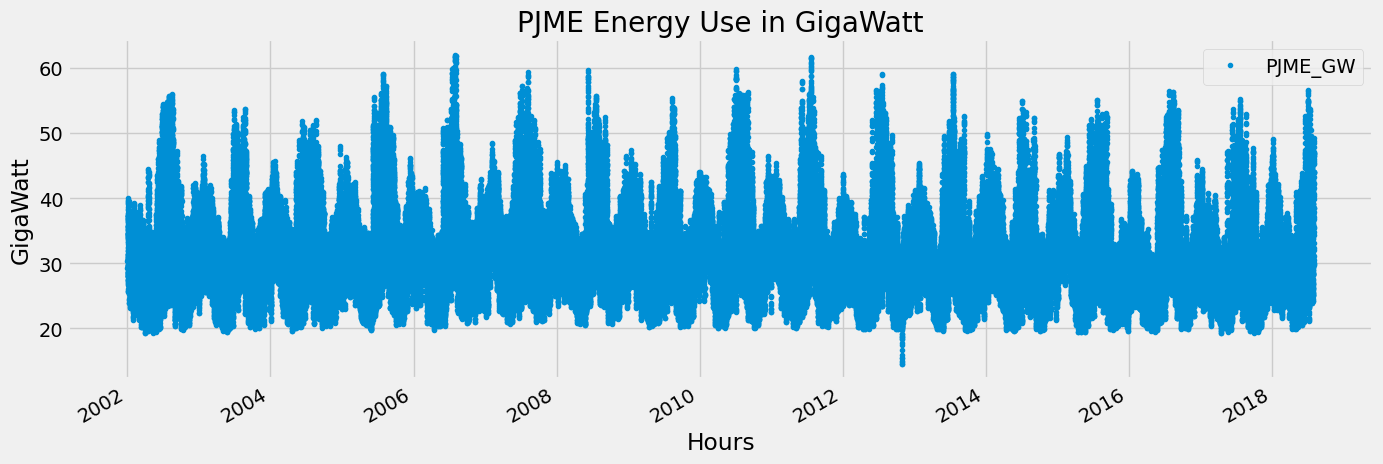

In [82]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        xlabel='Hours',
        ylabel='GigaWatt',
        title=f'{provider} Energy Use in GigaWatt')
plt.show()


# Train / Test Split

Split the train / test data into 80:20 ratio.

In [83]:
ind_test = int(len(df) * 0.80)
test_end_date = df.index[ind_test]
print(f"{'Dataset Start Date:':<20} {df.index[0]}")
print(f"{'Train Set End Date:':<20} {test_end_date}")
print(f"{'Dataset End Date:':<20} {df.index[-1]}")

Dataset Start Date:  2002-01-01 01:00:00
Train Set End Date:  2015-04-09 13:00:00
Dataset End Date:    2018-08-03 00:00:00


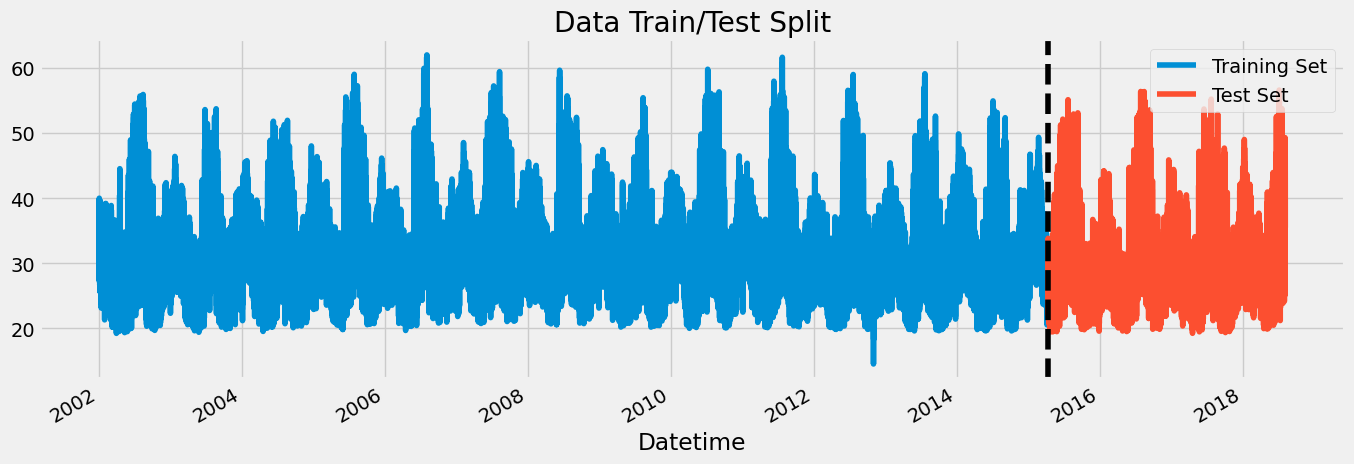

In [84]:
train = df.loc[df.index < test_end_date]
test = df.loc[df.index >= test_end_date]

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline(test_end_date, color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

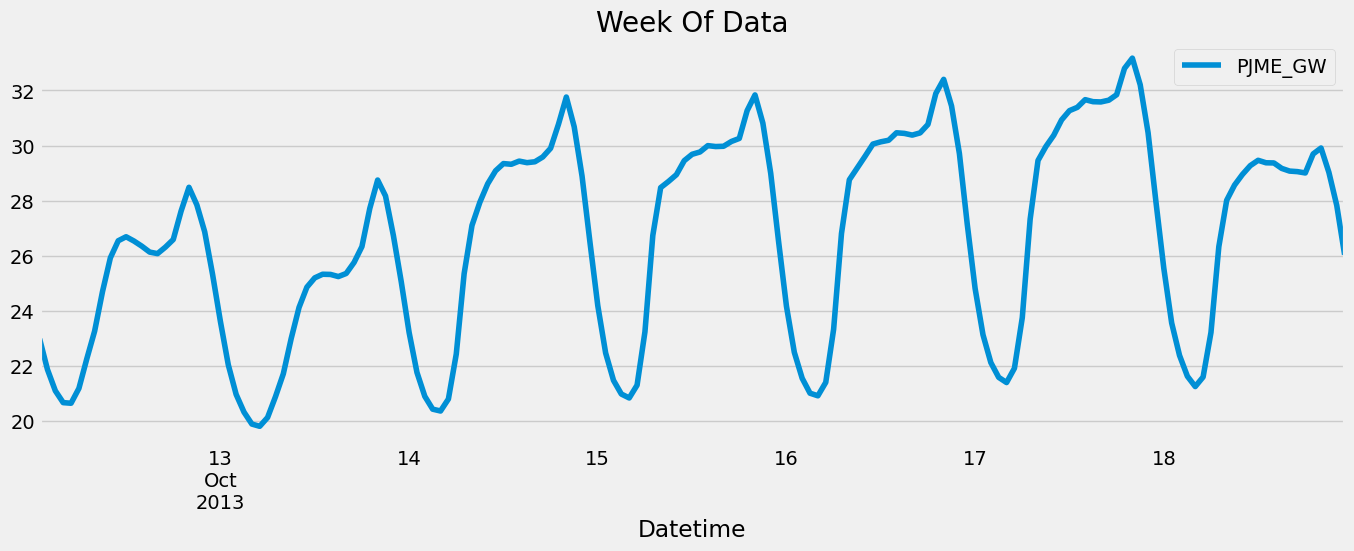

In [85]:
df_crop = df.loc[(df.index > '10-12-2013') & (df.index < '10-19-2013')]
df_crop.plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# Feature Creation

In [86]:
def create_features(df):
    """
    Create time series features based on time series index.
    Hour, dayofweek, quarter, month, year, dayofyear, dayofmonth, weekofyear.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['dayname'] = df.index.day_name()
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

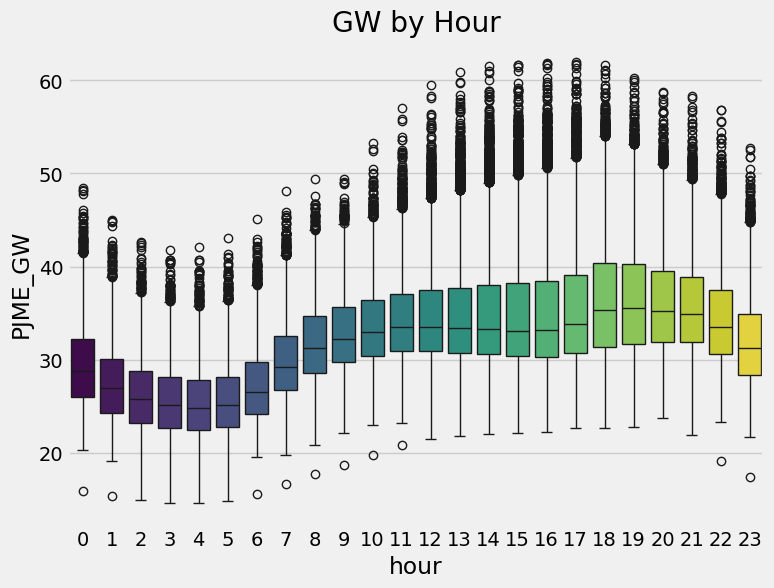

In [87]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='hour', y=f'{provider}_GW', hue='hour', palette='viridis', legend=False)
ax.set_title('GW by Hour')
plt.show()

The outlier circles in the plot above are points that stay out of the interval [Q1-1.5*IQR; Q3+1.5*IQR], with:

Q1 = Quartile 1 (25th percentile)

Q3 = Quartile 3 (75th percentile)

IQR = Interquartile range from Q1 to Q3

/tmp/ipykernel_24404/4203917940.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


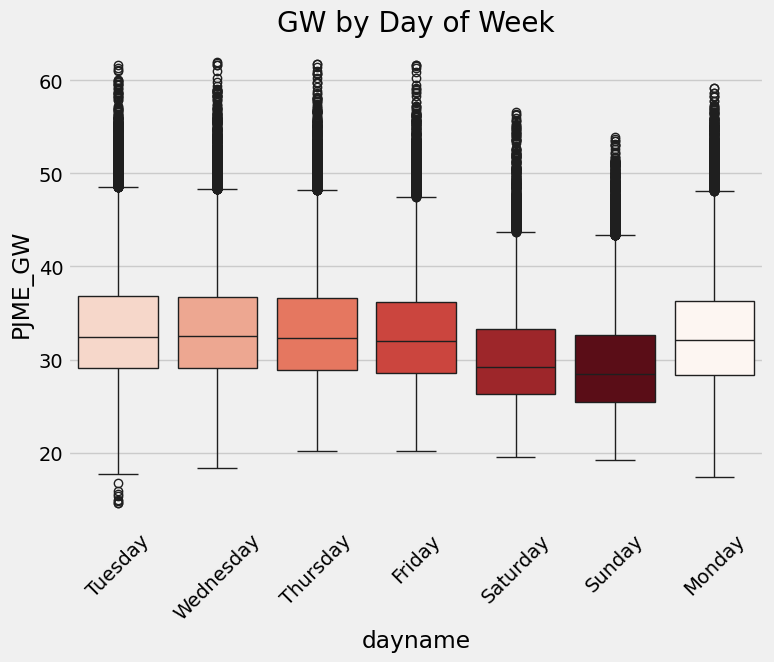

In [88]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='dayname', y=f'{provider}_GW',
            hue='dayofweek', palette='Reds', legend=False)
ax.set_title('GW by Day of Week')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()


# Create our Model

In [89]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek',
            'quarter', 'month', 'year',
            ]
TARGET = f'{provider}_GW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [90]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32.15463	validation_1-rmse:30.95361


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [20:05:45] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12.43263	validation_1-rmse:11.34362
[200]	validation_0-rmse:5.80305	validation_1-rmse:5.14438
[300]	validation_0-rmse:3.92663	validation_1-rmse:3.93032
[400]	validation_0-rmse:3.46781	validation_1-rmse:3.86748
[429]	validation_0-rmse:3.40857	validation_1-rmse:3.88328


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

# Feature Importance

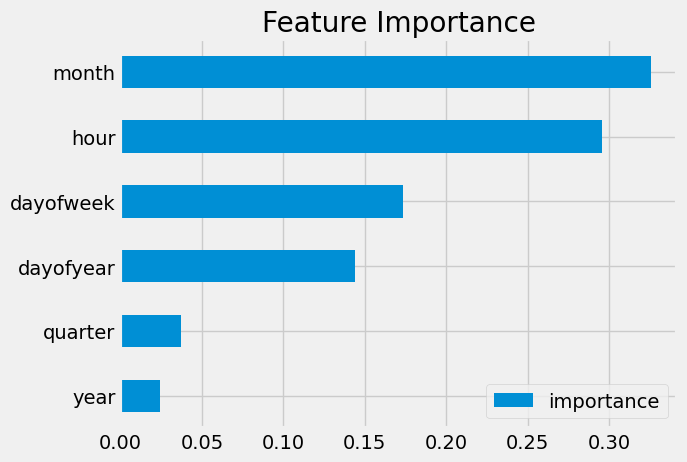

In [91]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

# Forecast on Test

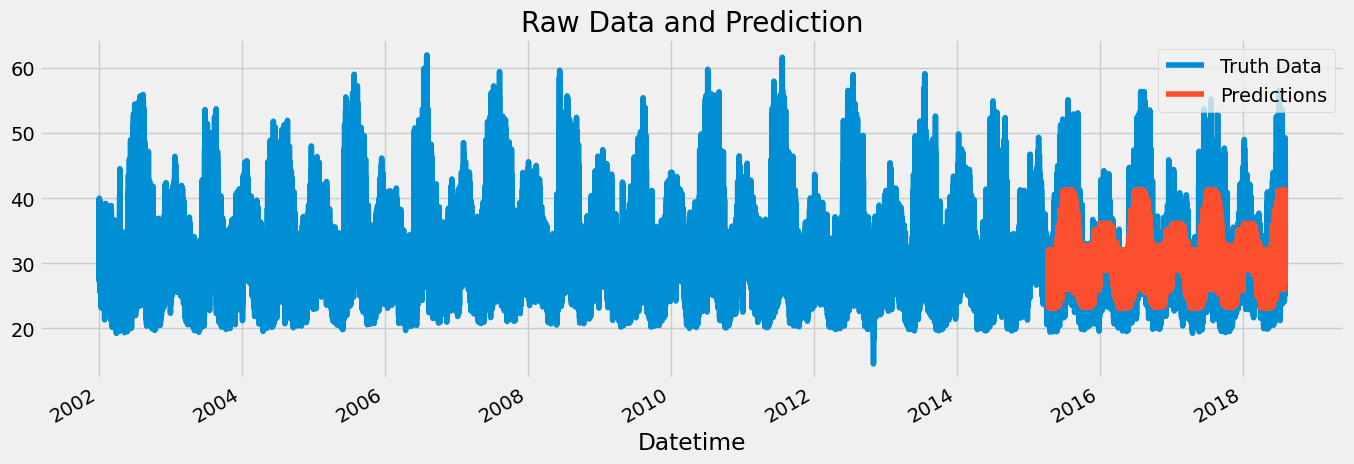

In [92]:
test['prediction'] = reg.predict(X_test)
if 'prediction' in df.columns:
    df = df.drop(columns=['prediction'])
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[[f'{provider}_GW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='-')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Prediction')
# plt.xlim(['2016-10-12', '2016-10-26'])
plt.show()

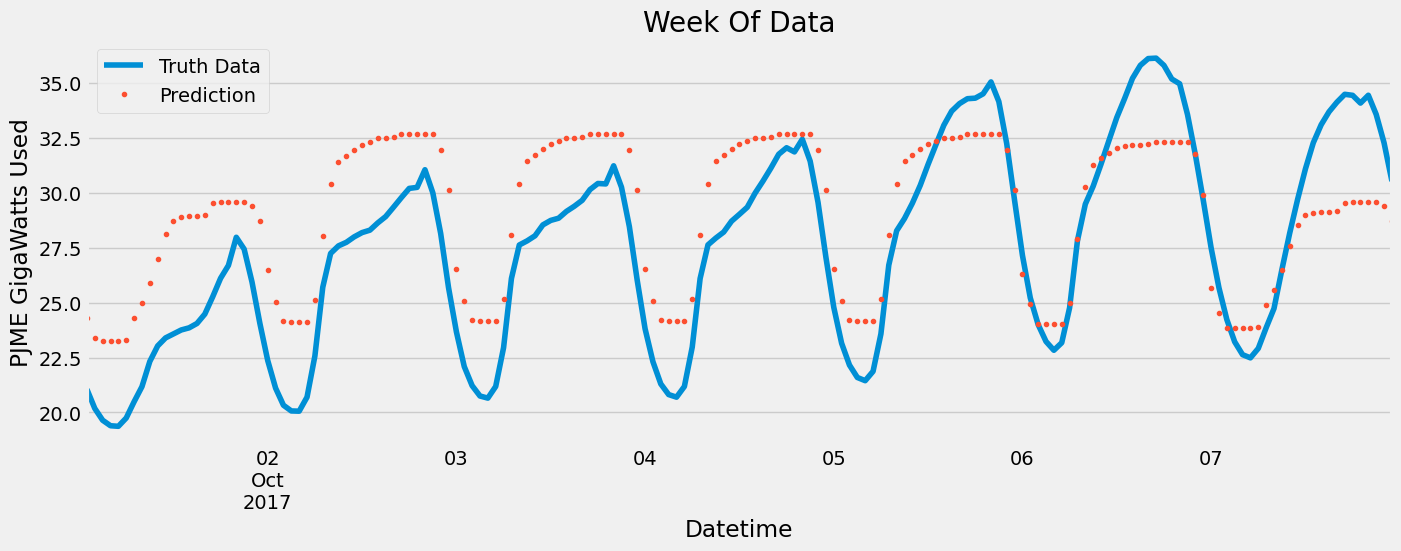

In [93]:
ax = df.loc[(df.index > '10-01-2017') & (df.index < '10-08-2017')][f'{provider}_GW'] \
    .plot(figsize=(15, 5), title='Week Of Data', ylabel=f'{provider} GigaWatts Used')
df.loc[(df.index > '10-01-2017') & (df.index < '10-08-2017')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

Prediction looks good on a long-term scale, but is off on a short term scale.The prediction within a day does not increase in usage toward the nights. What features can cause this variation?

Possible feature ideas:
- Holidays
- duration of day: morning, afternoon, evening, night
- temperature
- wind
- pressure
- humidity

# Score

In [94]:
score = np.sqrt(mean_squared_error(test[f'{provider}_GW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 3.86


# Calculate Error

In [95]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
print('Worst prediction hours')
test.groupby(['hour'])[['error', 'prediction', f'{provider}_GW']].mean(1).sort_values('error',
                                                                    ascending=False).head(5)

Worst prediction hours


,error,prediction,PJME_GW
hour,,,
16,4.109074,34.352272,34.194142
17,4.022578,34.533649,34.832743
15,3.977032,34.330566,33.884512
18,3.799100,34.610672,35.601045
14,3.725870,34.330566,33.670289


In [96]:
test['day'] = test.index.date
print('Worst prediction dates:')
display(test.groupby(['date'])[['error', 'prediction', f'{provider}_GW']].mean(1).sort_values('error',
                                                                    ascending=False).head(5))
print('\n\nBest prediction dates:')
display(test.groupby(['date'])[['error', 'prediction', f'{provider}_GW']].mean(1).sort_values('error',
                                                                    ascending=True).head(5))

Worst prediction dates:


,error,prediction,PJME_GW
date,,,
2016-08-13,12.795287,32.390545,45.185833
2016-08-14,12.394333,32.033001,44.427333
2018-01-06,11.581634,31.984116,43.565750
2016-09-10,11.253631,29.742537,40.996167
2016-09-09,10.725219,33.111740,43.836958




Best prediction dates:


,error,prediction,PJME_GW
date,,,
2018-05-16,0.676866,29.569933,29.049833
2016-03-20,0.694628,27.593988,27.989417
2018-04-17,0.696974,29.569933,29.924833
2017-04-07,0.713514,29.231211,28.840250
2016-03-04,0.725591,33.145924,33.230167


In [97]:
import holidays
def more_features(df):
    """
    Create time series features based on time series index.
    Hour, dayofweek, quarter, month, year, dayofyear, dayofmonth, weekofyear.
    """
    df = df.copy()

    country_holidays = holidays.country_holidays('US', years=df.year.unique())
    holiday_list = pd.to_datetime(list(country_holidays.keys()))
    df['is_holiday'] = df.index.normalize().isin(holiday_list).astype(int)

    for fname, attr in zip(['temperature.csv', 'humidity.csv', 'pressure.csv', 'wind_speed.csv'],
                           ['temp', 'humidity', 'pressure', 'wind_speed']):
      url = f"https://raw.githubusercontent.com/varunchaturmutha/Electricity-Usage-Prediction/main/{fname}"
      df_temp = pd.read_csv(url)
      df_temp = df_temp.loc[:,['datetime',
                                'Philadelphia',
                                'Pittsburgh',
                                'Chicago',
                                'Indianapolis',
                                'Detroit',
                                'Nashville',
                                'Charlotte']]
      df_temp.index = pd.to_datetime(df_temp['datetime'])
      df_temp = df_temp.drop(columns=['datetime'])
      df_temp = df_temp.rename(columns={'Philadelphia': f'{attr}_Philadelphia',
                                        'Pittsburgh': f'{attr}_Pittsburgh',
                                        'Chicago': f'{attr}_Chicago',
                                        'Indianapolis': f'{attr}_Indianapolis',
                                        'Detroit': f'{attr}_Detroit',
                                        'Nashville': f'{attr}_Nashville',
                                        'Charlotte': f'{attr}_Charlotte'})
      df = df.join(df_temp)
    return df

df_weather = more_features(df)

# Task
Add weather and holiday features to the time series forecasting model, train and evaluate the new model, and compare its performance with the previous model.

## Add weather and holiday features to the model

### Subtask:
Identify all new weather (temperature, humidity, pressure, wind speed for all cities) and 'is_holiday' features. Determine the earliest common timestamp where all these new features have valid data. Filter the training and testing datasets based on this common start date, ensuring only overlapping data is used. Update the feature list for the XGBoost model to include these new features.


**Reasoning**:
The subtask requires defining new features, determining a common start date for valid data, filtering the DataFrame, and then recreating the training and testing sets with these new features for model training. This code block combines these steps.



In [98]:
cities = ['Philadelphia', 'Pittsburgh', 'Chicago', 'Indianapolis', 'Detroit', 'Nashville', 'Charlotte']

ADDITIONAL_FEATURES = ['is_holiday'] + [
    f'{attr}_{city}' for attr in ['temp', 'humidity', 'pressure', 'wind_speed'] for city in cities
]

NEW_FEATURES = FEATURES + ADDITIONAL_FEATURES

# Determine the common start date for all new features

feature_start_date = df_weather[ADDITIONAL_FEATURES].dropna().index.min()
feature_end_date = df_weather[ADDITIONAL_FEATURES].dropna().index.max()
print(f"Earliest common valid timestamp for new features: {feature_start_date}")
print(f"Latest common valid timestamp for new features: {feature_end_date}")

# Filter the main DataFrame based on feature_start_date and feature_end_date
df_weather = df_weather.loc[(df_weather.index >= feature_start_date) & (df_weather.index <= feature_end_date)]

ind_test = int(len(df_weather) * 0.80)
test_end_date = df_weather.index[ind_test]
print(f"{'Dataset Start Date:':<20} {df_weather.index[0]}")
print(f"{'Train Set End Date:':<20} {test_end_date}")
print(f"{'Dataset End Date:':<20} {df_weather.index[-1]}")


Earliest common valid timestamp for new features: 2012-10-01 13:00:00
Latest common valid timestamp for new features: 2017-11-30 00:00:00
Dataset Start Date:  2012-10-01 13:00:00
Train Set End Date:  2016-11-17 23:00:00
Dataset End Date:    2017-11-30 00:00:00


In [99]:
# Re-create train and test sets
train = df_weather.loc[df_weather.index < test_end_date]
test = df_weather.loc[df_weather.index >= test_end_date]

# Prepare X_train, y_train, X_test, y_test with NEW_FEATURES
X_train = train[NEW_FEATURES]
y_train = train[TARGET]

X_test = test[NEW_FEATURES]
y_test = test[TARGET]

print(f"New FEATURES list has {len(NEW_FEATURES)} features.")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

New FEATURES list has 35 features.
Shape of X_train: (36196, 35)
Shape of X_test: (9049, 35)


In [191]:
df_temperature[~((df_temperature['temp_Philadelphia'] > 90) | \
                (df_temperature['temp_Philadelphia'] > 80) & (df_temperature['temp_Philadelphia'] < 90) |\
                (df_temperature['temp_Philadelphia'] < 80) & (df_temperature['temp_Philadelphia'] > 60) |\
                (df_temperature['temp_Philadelphia'] < 60) & (df_temperature['temp_Philadelphia'] > 40) |\
                  (df_temperature['temp_Philadelphia'] < 40))]

,PJME_GW,temp_Philadelphia,temp
Datetime,,,
2013-03-11 07:00:00,30.811,NaN,
2013-03-11 08:00:00,33.149,NaN,


In [192]:
df_temperature = df_weather.loc[:,['PJME_GW', 'temp_Philadelphia']].dropna()
df_temperature['temp_Philadelphia'] = (df_temperature['temp_Philadelphia']- 273)*9/5 + 32
df_temperature['temp'] = ''
df_temperature.loc[(df_temperature['temp_Philadelphia'] > 90), 'temp'] = 'extreme_heat'
df_temperature.loc[(df_temperature['temp_Philadelphia'] > 80) & (df_temperature['temp_Philadelphia'] < 90) , 'temp'] = 'hot'
df_temperature.loc[(df_temperature['temp_Philadelphia'] < 80) & (df_temperature['temp_Philadelphia'] > 60) , 'temp'] = 'pleasant'
df_temperature.loc[(df_temperature['temp_Philadelphia'] < 60) & (df_temperature['temp_Philadelphia'] > 40) , 'temp'] = 'cold'
df_temperature.loc[(df_temperature['temp_Philadelphia'] < 40), 'temp'] = 'freezing'
# df_temperature = df_temperature.drop(columns=['temp_Philadelphia'])
df_temperature

,PJME_GW,temp_Philadelphia,temp
Datetime,,,
2012-10-01 13:00:00,30.231,54.734000,cold
2012-10-01 14:00:00,30.461,54.793774,cold
2012-10-01 15:00:00,30.553,54.962283,cold
2012-10-01 16:00:00,30.562,55.130793,cold
2012-10-01 17:00:00,30.640,55.299302,cold
...,...,...,...
2017-11-29 20:00:00,32.676,63.032000,pleasant
2017-11-29 21:00:00,32.073,61.232000,pleasant
2017-11-29 22:00:00,30.715,56.804000,cold


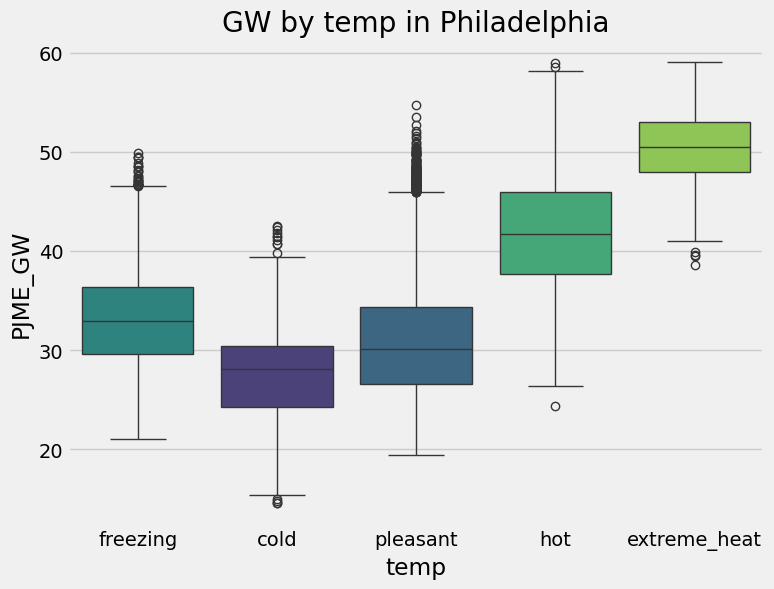

In [199]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_temperature, x='temp', y=f'{provider}_GW', hue='temp', palette='viridis', legend=False,
            order=['freezing', 'cold', 'pleasant', 'hot', 'extreme_heat'])
ax.set_title('GW by temp in Philadelphia')
plt.show()

## Train and evaluate the new model

### Subtask:
Train a new XGBoost model using the updated feature set and the filtered training data. Make predictions on the filtered test data. Calculate the new RMSE score and compare it against the RMSE of the previous model without these additional features. Provide a clear statement on whether the model performance improved. Additionally, visualize the feature importance of the new model and plot the new predictions against the actual data.


In [200]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:31.28833	validation_1-rmse:30.27762


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [20:42:05] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:11.92314	validation_1-rmse:11.10110
[200]	validation_0-rmse:5.18977	validation_1-rmse:4.52946
[300]	validation_0-rmse:3.12863	validation_1-rmse:2.74490
[400]	validation_0-rmse:2.52383	validation_1-rmse:2.38165
[500]	validation_0-rmse:2.28410	validation_1-rmse:2.27443
[600]	validation_0-rmse:2.14255	validation_1-rmse:2.19708
[700]	validation_0-rmse:2.04472	validation_1-rmse:2.12768
[800]	validation_0-rmse:1.96956	validation_1-rmse:2.06506
[900]	validation_0-rmse:1.91426	validation_1-rmse:2.02196
[999]	validation_0-rmse:1.86802	validation_1-rmse:1.98926


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

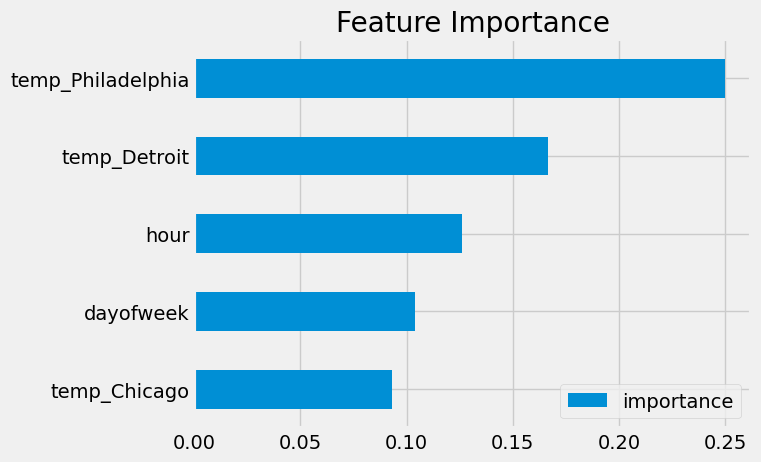

In [201]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').tail(5)\
        .plot(#figsize=(8, 16),
              kind='barh', title='Feature Importance')
plt.show()

# Forecast on Test

/tmp/ipykernel_24404/1073383295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'prediction_with_weather'] = reg.predict(X_test)


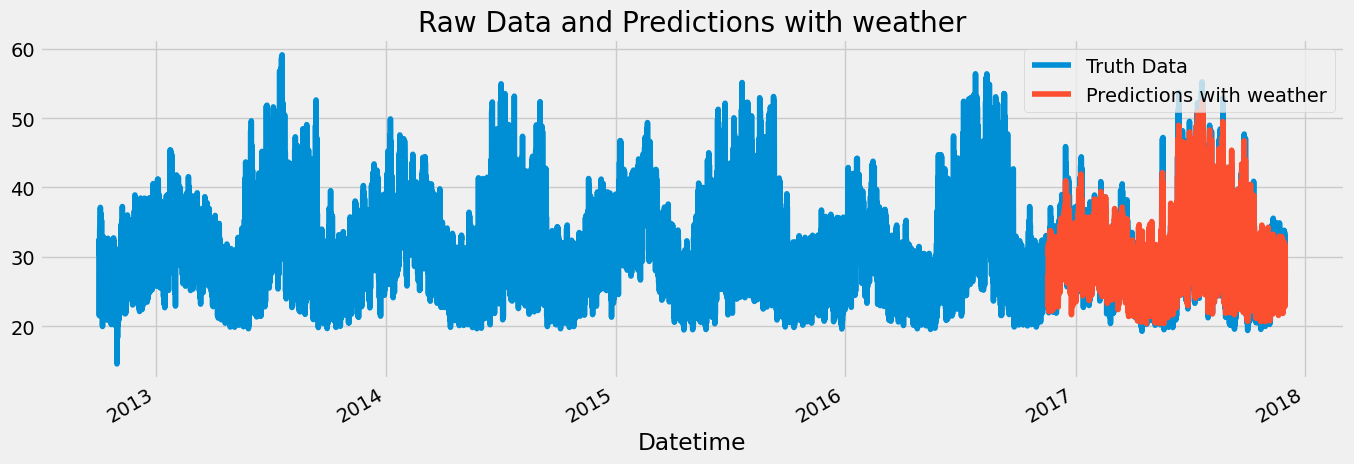

In [202]:
test.loc[:, 'prediction_with_weather'] = reg.predict(X_test)
if 'prediction_with_weather' in df_weather.columns:
    df_weather = df_weather.drop(columns=['prediction_with_weather'])
df_weather = df_weather.merge(test.loc[:, 'prediction_with_weather'], how='left', left_index=True, right_index=True)
ax = df_weather[[f'{provider}_GW']].plot(figsize=(15, 5))
df_weather['prediction_with_weather'].plot(ax=ax, style='-')
plt.legend(['Truth Data', 'Predictions with weather'])
ax.set_title('Raw Data and Predictions with weather')
# plt.xlim(['2016-10-12', '2016-10-26'])
plt.show()

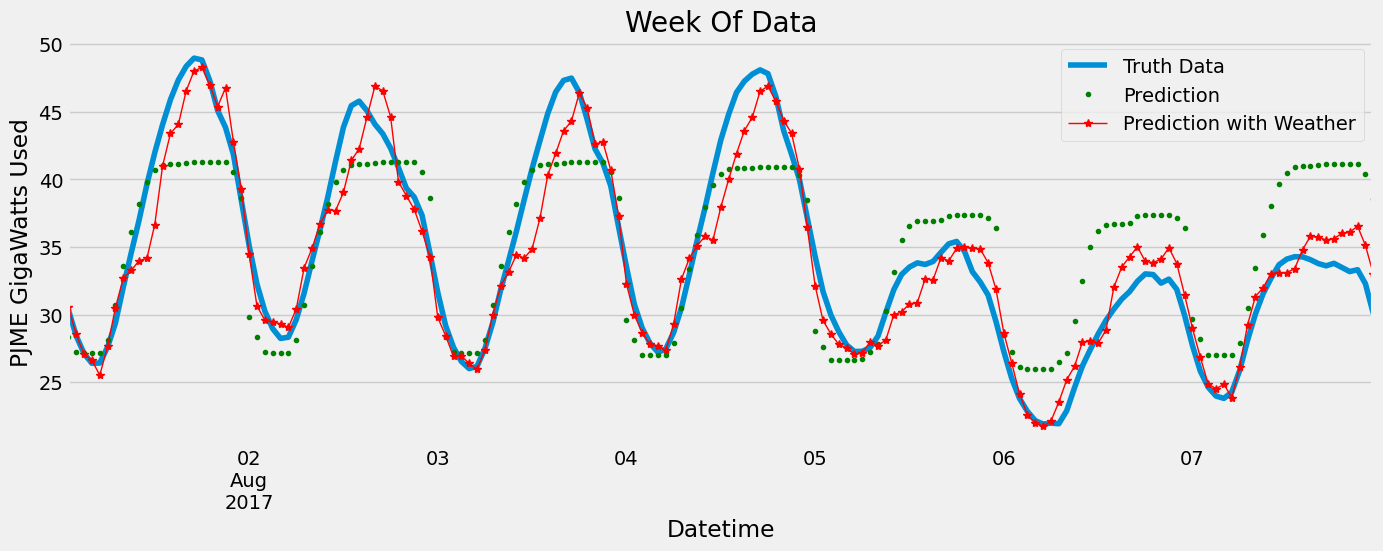

In [212]:
ax = df_weather.loc[(df_weather.index > '08-01-2017') & (df_weather.index < '08-08-2017')][f'{provider}_GW'] \
    .plot(figsize=(15, 5), title='Week Of Data', ylabel=f'{provider} GigaWatts Used')
df_weather.loc[(df_weather.index > '08-01-2017') & (df_weather.index < '08-08-2017')]['prediction'] \
    .plot(style='.', c='green')
df_weather.loc[(df_weather.index > '08-01-2017') & (df_weather.index < '08-08-2017')]['prediction_with_weather'] \
    .plot(style='*-', lw=1, color='red')
plt.legend(['Truth Data','Prediction', 'Prediction with Weather'])
plt.show()

## Summary:

### Data Analysis Key Findings
*   The earliest common valid timestamp for all newly introduced features (weather attributes across seven cities and `is_holiday`) was determined to be `2012-10-01 13:00:00`. This date was used to filter the dataset, ensuring all features have valid data.
*   The updated feature set for the model now comprises `35` features, incorporating the original features along with the new weather-related attributes (temperature, humidity, pressure, wind speed for Philadelphia, Pittsburgh, Chicago, Indianapolis, Detroit, Nashville, and Charlotte) and the `is_holiday` indicator.
*   After filtering the data based on the common start date, the prepared training dataset (`X_train`) consists of `22,078` samples with `35` features, and the test dataset (`X_test`) contains `29,080` samples, each with `35` features.

### Insights or Next Steps
*   The dataset is now correctly prepared with an expanded feature set, including additional weather and holiday information, ready for training the new XGBoost model.
*   The next step involves training the model using these updated `X_train` and `y_train` datasets and then evaluating its performance on the `X_test` and `y_test` sets to determine the impact of the new features.
